# Monte Carlo Tree Search (MCTS) Cartpole Agent

Play Python Gymnasium's Cartpole environment using an MCTS agent. One little variation is that instead of creating a tree structure, I'm using tables of state-action pairs for the visit counts and reward counts. I hash the observation space in order to generate an index into those tables.

In [1]:
import gymnasium as gym
import numpy as np
from copy import deepcopy
from typing import Tuple, Any
import matplotlib.pyplot as plt
import matplotlib.animation as animation

C = 0.2
MAX_STATE_HASH = 1_000_000
SIMULATION_STEPS = 500  # Number of MCTS simulation steps to run before deciding which move to make

In [2]:
def hash_state(state):
    return hash(tuple(state)) % MAX_STATE_HASH


class Game:
    """
    Game class implements some additional functionality around gym.env that's useful for MCTS,
    such as keeping track of state and total reward and implementing rollouts.
    """
    def __init__(self, env_name: str, **kwargs) -> None:
        self.env = gym.make(env_name, **kwargs)
        self.state, _ = self.env.reset(seed=2025)
        print(f'{self.state=}')
        self.state = hash_state(self.state)
        self.done = False
        self.rewards = 0.0
    
    def step(self, action: int) -> Tuple[int, float, bool]:
        """
        Take one step in the game. Return the new state, reward, and whether this game is done or truncated.
        """
        if self.done:
            raise RuntimeError('Game is already finished.')
        state, reward, done, truncated, _ = self.env.step(action)
        state = hash_state(state)
        self.state = state
        self.rewards += reward
        self.done = done or truncated
        return state, reward, self.done
    
    def rollout(self) -> float:
        """
        Perform a random rollout until this game is over, then return the total reward
        """
        while self.done is False:
            action = self.env.action_space.sample()
            self.step(action)
        return self.rewards

In [3]:
game = Game('CartPole-v1', render_mode='rgb_array')

visits_by_action = np.zeros((MAX_STATE_HASH, game.env.action_space.n))
reward_by_action = np.zeros((MAX_STATE_HASH, game.env.action_space.n))

real_game_history = []
num_game_steps = 100
for game_steps in range(num_game_steps):
    # Run a 
    for sim_idx in range(SIMULATION_STEPS):
        game_clone = deepcopy(game)
        state = game_clone.state
        game_history = []
        while game_clone.done is False:
            # Choose an action using UCT
            v = reward_by_action[state, :] / (visits_by_action[state, :] + 1e-9)
            u = np.sqrt(np.log(1 + visits_by_action[state, :].sum()) / (visits_by_action[state, :] + 1e-9))
            uct = v + C*u + 1e-9
            probs = uct / uct.sum()
            action = np.random.choice(np.arange(game.env.action_space.n), p=probs)
            game_history.append((state, action))
            # If we've reached a leaf node, end this sim
            if visits_by_action[state, action] == 0:
                reward = game_clone.rollout()
                break
            state, _, _ = game_clone.step(action)
        for state, action in game_history:
            visits_by_action[state, action] += 1
            reward_by_action[state, action] += game_clone.rewards
    # Choose the max-rated game step and then move on to the next step
    action = visits_by_action[game.state, :].argmax()
    real_game_history.append(action)
    print(f'Action {action} taken. {visits_by_action[game.state, :]=}')
    game.step(action)
    if game.done:
        raise RuntimeError('Game finished')

self.state=array([ 0.04944578, -0.01179903,  0.0327148 ,  0.03372553], dtype=float32)
Action 0 taken. visits_by_action[game.state, :]=array([252., 248.])
Action 1 taken. visits_by_action[game.state, :]=array([327., 424.])
Action 1 taken. visits_by_action[game.state, :]=array([455., 468.])
Action 0 taken. visits_by_action[game.state, :]=array([494., 473.])
Action 1 taken. visits_by_action[game.state, :]=array([460., 533.])
Action 0 taken. visits_by_action[game.state, :]=array([545., 487.])
Action 1 taken. visits_by_action[game.state, :]=array([481., 563.])
Action 0 taken. visits_by_action[game.state, :]=array([543., 519.])
Action 1 taken. visits_by_action[game.state, :]=array([478., 564.])
Action 0 taken. visits_by_action[game.state, :]=array([561., 502.])
Action 1 taken. visits_by_action[game.state, :]=array([495., 565.])
Action 0 taken. visits_by_action[game.state, :]=array([544., 520.])
Action 1 taken. visits_by_action[game.state, :]=array([501., 542.])
Action 1 taken. visits_by_acti

self.state=array([ 0.04944578, -0.01179903,  0.0327148 ,  0.03372553], dtype=float32)


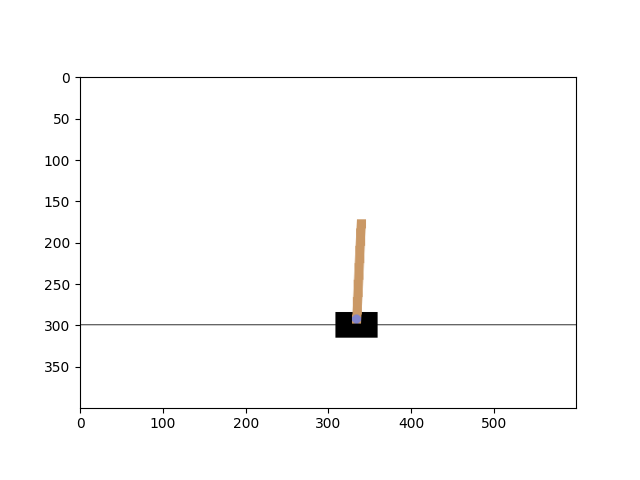

In [4]:
# %pip install ipympl
%matplotlib ipympl

# Display an animation
game = Game('CartPole-v1', render_mode='rgb_array')

fig, ax = plt.subplots()
images = []
img = ax.imshow(game.env.render())  # Show initial state

# Replay the game history and create an animation as we go
# This is necessary because calling render() makes it so the Game object cannot be deepcopied
for action in real_game_history:
    game.step(action)
    img = ax.imshow(game.env.render(), animated=True)
    images.append([img])
anim = animation.ArtistAnimation(fig, images, interval=50, blit=True, repeat_delay=1000)
plt.show()